# Logit Model


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from arviz_base import convert_to_dataset
from arviz_stats import summary
from polyagamma import random_polyagamma
from scipy.linalg import inv, solve
from scipy.stats import gaussian_kde, logistic
from tqdm import trange
rng = np.random.default_rng(seed=99)

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_dataset(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                          for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, ci_prob=prob, ci_kind='hdi', round_to='none')
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

## Gibss sampler for the logit model

The full conditional posterior distributions of $\beta$ and $\omega_{i}$  ($i=1,\dots,n$) are

$$
    \begin{split}
        \beta|\omega,D &\sim \mathrm{Normal}(\beta_{\star},\Sigma_{\star}), \\
        \omega_{i}|\beta,D &\sim \mathrm{PG}(1, x_{i}^{\intercal}\beta),\quad (i=1,\dots,n),
      \end{split}
$$

where

$$
    \beta_{\star} = (X^{\intercal}\Omega X + A_{0})^{-1}(X^{\intercal}\kappa+A_{0}\beta_{0}),\quad \Sigma_{\star} = (X^{\intercal}\Omega X + A_{0})^{-1},
$$

$$
    \kappa = \begin{bmatrix} y_{1}-\frac12 \\ \vdots \\ y_{n}-\frac12 \end{bmatrix},\quad \Omega = \begin{bmatrix} \omega_{1} & & \\ & \ddots & \\ & & \omega_{n}\end{bmatrix}.
$$


In [4]:
def gibbs_logit(y, X, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for logit model

    Inputs
    y       --- regressand (n x 1)
    X       --- regressors (n x k)
    hyper_param = [b0, A0]
    b0      --- the prior mean vector of the regression coefficients
    A0      --- the prior precision matrix of the regression coefficients
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample ((burnin + draws) x k)
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    b0, A0 = hyper_param
    kappa = y - 0.5
    n, k = X.shape
    b = solve(X.T @ X, X.T @ kappa)
    A0b0 = A0 @ b0
    XkappaA0b0 = X.T @ kappa + A0b0
    runs = np.empty((iterations, k))
    for it in trange(iterations):
        Omega = np.diag(random_polyagamma(1.0, X @ b, random_state=rng))
        cov_b = inv(X.T @ Omega @ X + A0)
        mean_b = cov_b @ XkappaA0b0
        b = rng.multivariate_normal(mean_b, cov_b)
        runs[it, :] = b
    return runs

In [5]:
n = 500
x1 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
x2 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
q = logistic.cdf(0.5*x1 - 0.5*x2)
y = rng.binomial(1, q)
X = np.stack((np.ones(n), x1, x2), axis=1)
n, k = X.shape
b0 = np.zeros(k)
A0 = 0.01 * np.eye(k)
hyper_param = [b0, A0]

## Gibbs sampler


In [6]:
burnin = 5000
draws = 20000
runs_gibbs = gibbs_logit(y, X, hyper_param, burnin=burnin, draws=draws, rng=rng)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:04<00:00, 5267.89it/s]


In [7]:
results_gibbs = mcmc_stats(runs_gibbs, burnin=burnin, isvariance=False)
display(results_gibbs)

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
$\beta_0$,0.103462,0.095304,-0.083428,0.28830,16962.232339,18218.779277,1.000643,0.000732,0.000479
$\beta_1$,0.498125,0.099290,0.301587,0.68902,16550.104005,18105.549071,1.000094,0.000772,0.000508
$\beta_2$,-0.518737,0.099804,-0.704751,-0.31623,15762.540944,17668.285759,1.000072,0.000795,0.000501


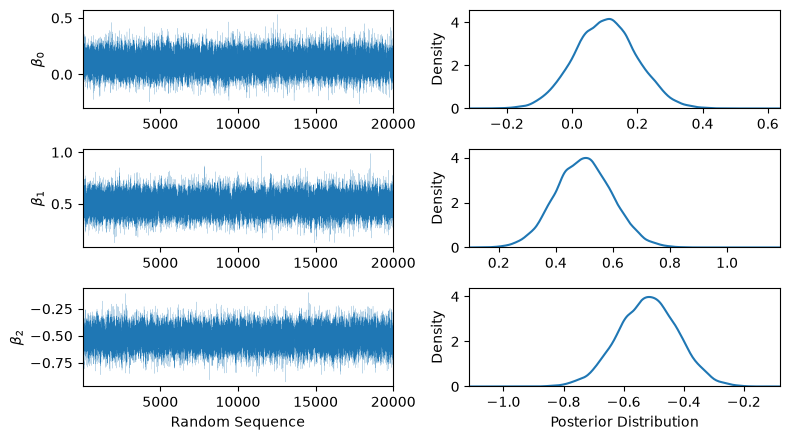

In [8]:
_ = mcmc_plots(runs_gibbs, burnin=burnin, isvariance=False)

## Implementation with PyMC


In [9]:
logit_model = pm.Model()
with logit_model:
    b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    idx = X @ b
    likelihood = pm.Bernoulli('y', p=pm.math.invlogit(idx), observed=y)

In [10]:
n_draws = 5000
n_chains = 4
n_tune = 5000
with logit_model:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, target_accept=0.9, random_seed=rng)
runs_pymc = np.vstack([trace.posterior['b'].to_numpy()[:, :, index].flatten() for index in range(k)]).T

NUTS[nutpie]: [b]


Output()

In [11]:
results_pymc = mcmc_stats(runs_pymc, isvariance=False)
display(results_pymc)

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
$\beta_0$,0.104527,0.095184,-0.088807,0.283548,20960.979741,15714.639177,1.000067,0.000657,0.000642
$\beta_1$,0.497492,0.098894,0.296051,0.686752,20215.109609,16202.341738,0.999998,0.000696,0.000659
$\beta_2$,-0.520296,0.101438,-0.717628,-0.323613,18907.086749,15876.162930,1.000354,0.000738,0.000659


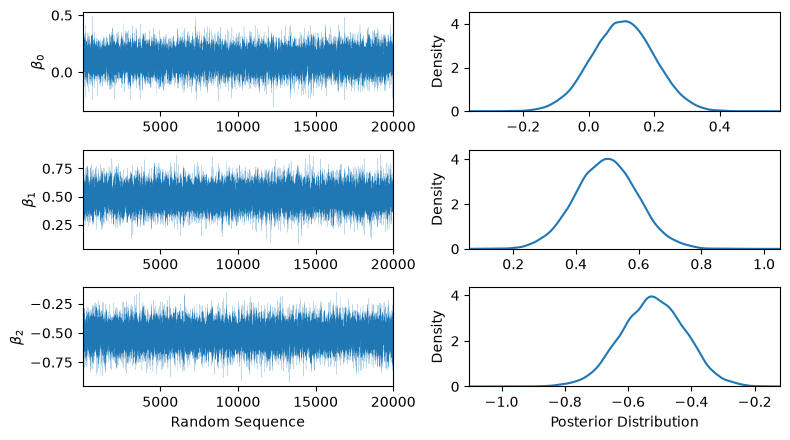

In [12]:
_ = mcmc_plots(runs_pymc, isvariance=False)